In [49]:
import sklearn as skl
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, median_absolute_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import os
import glob
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
import matplotlib.ticker as ticker
from sklearn.ensemble import RandomForestRegressor
import pickle
import gradio as gr


path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
csv_file = glob.glob(os.path.join(path, "*.csv"))[0]
df = pd.read_csv(csv_file)

print(df.columns.tolist())
print(df.shape)
df.head()

100%|██████████| 4.63k/4.63k [00:00<00:00, 5.88MB/s]

Extracting files...
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [51]:
print(df['price'].min())
print(df['price'].max())

1750000
13300000


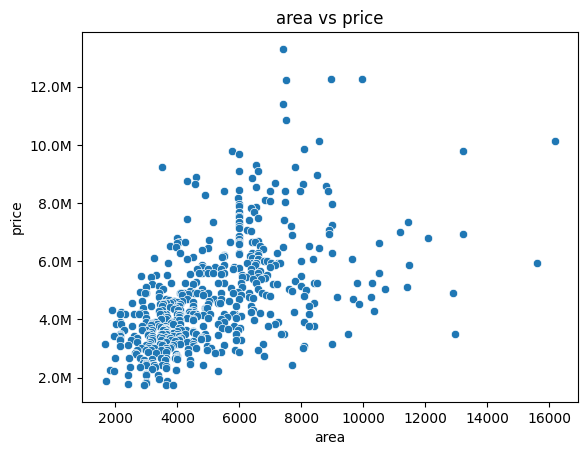

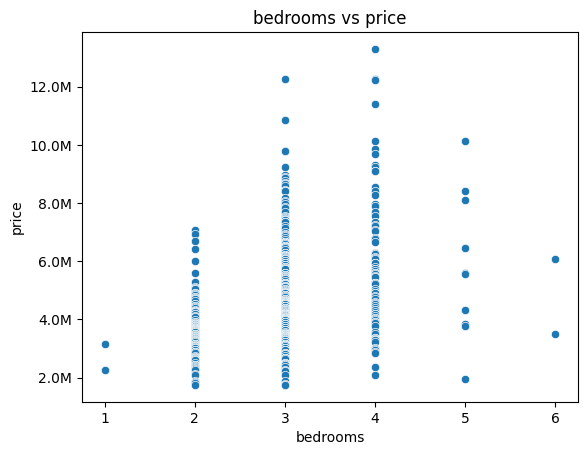

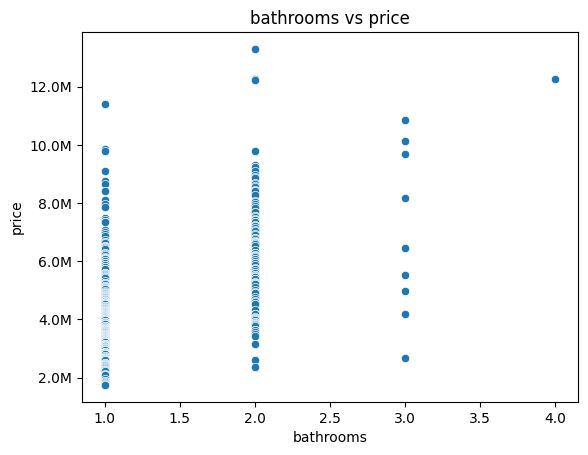

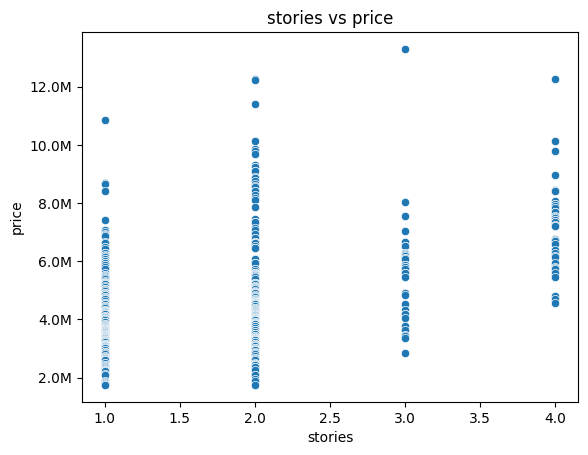

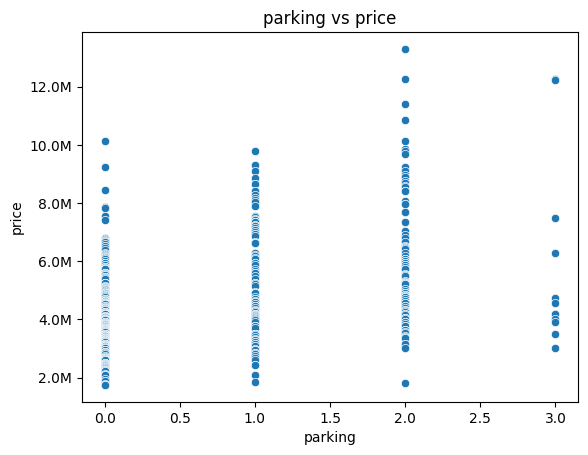

In [52]:
numeric_df = df.select_dtypes(include='number')

for col in numeric_df.columns:
    if col != 'price':
        ax = sns.scatterplot(data=df, x=col, y='price')
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1f}M'.format(x/1e6)))
        plt.title(f'{col} vs price')
        plt.show()

<Axes: >

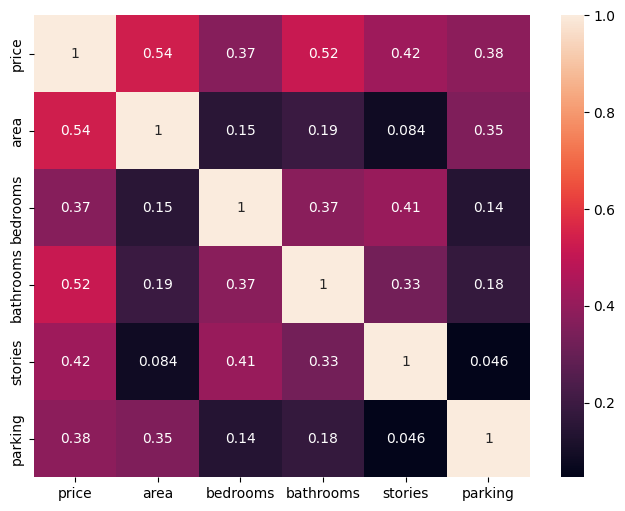

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)

In [54]:
X = numeric_df.drop(columns='price')
y = numeric_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

lasso = Lasso(alpha=100000)
lasso.fit(X_train_std, y_train)

Lasso(alpha=100000)

In [55]:
y_pred = lasso.predict(X_test_std)
r2 = r2_score(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
MAE = median_absolute_error(y_test, y_pred)

print(f'R2 score: {r2}\nRMSE score: {RMSE}\nMSE score: {MSE}\nMAE score: {MAE}')

R2 score: 0.5652288284666679
RMSE score: 1082306.961043981
MSE score: 1171388357924.2573
MAE score: 684843.6542991516


In [56]:
def models_eval(models, X, y):
    model_results = {}
    fitted_models = {}

    for name, model in models.items():
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=True, random_state=42)

        scaler = StandardScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        model.fit(X_train_std, y_train)
        y_pred = model.predict(X_test_std)

        r2 = r2_score(y_test, y_pred)
        RMSE = root_mean_squared_error(y_test, y_pred)
        MSE = mean_squared_error(y_test, y_pred)

        model_results[name] = {'R2': r2, 'RMSE': RMSE, 'MSE': MSE}
        fitted_models[name] = model

    return model_results, fitted_models

In [57]:
def save_best_model(models, results, metric='R2', higher_is_better=True, filename='best_model.pkl'):
    if higher_is_better:
        best_name = max(results, key=lambda name: results[name][metric])
    else:
        best_name = min(results, key=lambda name: results[name][metric])

    best_model = models[best_name]

    with open(filename, 'wb') as f:
        pickle.dump(best_model, f)

    print(f'Best model: {best_name} ({metric}={results[best_name][metric]})')
    return best_model, best_name

In [58]:
from sklearn.linear_model import LassoCV, RidgeCV
import numpy as np

alphas = np.logspace(-2, 6, 50)  # test wide range: 0.01 to 1,000,000

lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train_std, y_train)
print("Best Lasso alpha:", lasso_cv.alpha_)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_std, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_)

Best Lasso alpha: 5179.474679231202
Best Ridge alpha: 26.826957952797247


In [59]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=lasso_cv.alpha_),
    'Ridge': Ridge(alpha=ridge_cv.alpha_),
    'Random Forest Regressor': RandomForestRegressor()}

results, fitted_models = models_eval(models, X, y)
for name, metrics in results.items():
    print(name, metrics)

Linear Regression {'R2': 0.5647807908060096, 'RMSE': 1354665.756677407, 'MSE': 1835119312314.3716}
Lasso {'R2': 0.5639828300063777, 'RMSE': 1355907.0566017528, 'MSE': 1838483946142.4285}
Ridge {'R2': 0.559274395201205, 'RMSE': 1363208.4400428322, 'MSE': 1858337251004.0117}
Random Forest Regressor {'R2': 0.4555203937849184, 'RMSE': 1515196.4142901092, 'MSE': 2295820173877.604}


In [60]:
best_model, best_name = save_best_model(fitted_models, results)

Best model: Linear Regression (R2=0.5647807908060096)


In [61]:
!pip install gradio -q

In [62]:
# save scaler alongside model
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# load model + scaler
with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [64]:
def predict_price(area, bedrooms, bathrooms, stories, parking):
    input_data = np.array([[area, bedrooms, bathrooms, stories, parking]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    return f"Predicted Price: {prediction:,.0f}"

demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Area (sq ft)"),
        gr.Number(label="Bedrooms"),
        gr.Number(label="Bathrooms"),
        gr.Number(label="Stories"),
        gr.Number(label="Parking Spots"),
    ],
    outputs=gr.Text(label="Prediction"),
    title="House Price Predictor",
    description="Enter house features to predict price based on trained model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62efa1fa3f61428480.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
